# Person D
* Renovation Impact Analysis
* Temporal Trend Analysis
* K-means Clustering

## Preprocessing

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import statsmodels.api as sm

# Load the dataset
df = pd.read_csv("Dataset/AmesHousing.csv")
print(f"Dataset shape: {df.shape}")
print(f"First few rows:\n{df.head()}")

Dataset shape: (2930, 82)
First few rows:
   Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0      1  526301100           20        RL         141.0     31770   Pave   
1      2  526350040           20        RH          80.0     11622   Pave   
2      3  526351010           20        RL          81.0     14267   Pave   
3      4  526353030           20        RL          93.0     11160   Pave   
4      5  527105010           60        RL          74.0     13830   Pave   

  Alley Lot Shape Land Contour  ... Pool Area Pool QC  Fence Misc Feature  \
0   NaN       IR1          Lvl  ...         0     NaN    NaN          NaN   
1   NaN       Reg          Lvl  ...         0     NaN  MnPrv          NaN   
2   NaN       IR1          Lvl  ...         0     NaN    NaN         Gar2   
3   NaN       Reg          Lvl  ...         0     NaN    NaN          NaN   
4   NaN       IR1          Lvl  ...         0     NaN  MnPrv          NaN   

  Misc Val Mo Sold Yr Sold Sale 

In [19]:
# Data Preprocessing
# Following Person B's approach for consistency

# 1. Drop Order and PID columns
df = df.drop(["Order", "PID"], axis=1)
print(f"After dropping Order and PID: {df.shape}")

# 2. Separate numeric and categorical columns
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

print(f"Numeric columns: {len(num_cols)}")
print(f"Categorical columns: {len(cat_cols)}")

After dropping Order and PID: (2930, 80)
Numeric columns: 37
Categorical columns: 43


In [20]:
# 3. Create "years since renovation at sale" feature
# This measures how many years had passed between the last home update and the sale.
# We use the most recent of Year Built and Year Remod/Add as the last update year.
# Then we compute: Years Since Renovation = Yr Sold - Last Update Year.

# First, check the year columns
print("Year column statistics:")
print(f"Year Built - min: {df['Year Built'].min()}, max: {df['Year Built'].max()}")
print(f"Year Remod/Add - min: {df['Year Remod/Add'].min()}, max: {df['Year Remod/Add'].max()}")
print(f"Yr Sold - min: {df['Yr Sold'].min()}, max: {df['Yr Sold'].max()}")

# Derive last update year (built year or renovation year, whichever is more recent)
df['Last Update Year'] = df[['Year Built', 'Year Remod/Add']].max(axis=1)

# Compute years since renovation/update at the time of sale
df['Years Since Renovation'] = df['Yr Sold'] - df['Last Update Year']

# Guard against any potential negative values from data issues
df['Years Since Renovation'] = df['Years Since Renovation'].clip(lower=0)

print(
    f"\nYears Since Renovation - min: {df['Years Since Renovation'].min()}, "
    f"max: {df['Years Since Renovation'].max()}"
)
print(f"Years Since Renovation - mean: {df['Years Since Renovation'].mean():.2f}")

# Drop columns to avoid redundancy now that the derived feature exists
df = df.drop(['Year Remod/Add', 'Last Update Year'], axis=1)
print(f"\nAfter creating Years Since Renovation and dropping redundant columns: {df.shape}")

# 4. Fill missing values
# Numeric columns: fill with median
for col in num_cols:
    if col in df.columns:  # Check if column still exists
        df[col] = df[col].fillna(df[col].median())

# Categorical columns: fill with "None"
for col in cat_cols:
    if col in df.columns:  # Check if column still exists
        df[col] = df[col].fillna("None")

print(f"Missing values after imputation: {df.isnull().sum().sum()}")

# 5. One-hot encode categorical variables
df = pd.get_dummies(df, drop_first=True)
print(f"After one-hot encoding: {df.shape}")

Year column statistics:
Year Built - min: 1872, max: 2010
Year Remod/Add - min: 1950, max: 2010
Yr Sold - min: 2006, max: 2010

Years Since Renovation - min: 0, max: 60
Years Since Renovation - mean: 23.52

After creating Years Since Renovation and dropping redundant columns: (2930, 80)
Missing values after imputation: 0
After one-hot encoding: (2930, 277)


## Renovation Impact Analysis

Analyzing the association between years since renovation and sale price using multiple linear regression on log(SalePrice).

In [21]:
# Create log(SalePrice) for regression analysis
df['log_SalePrice'] = np.log(df['SalePrice'])

# Separate features and target
X = df.drop(['SalePrice', 'log_SalePrice'], axis=1)
y = df['log_SalePrice']

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nTarget variable (log(SalePrice)) statistics:")
print(f"Mean: {y.mean():.4f}")
print(f"Std: {y.std():.4f}")
print(f"Min: {y.min():.4f}")
print(f"Max: {y.max():.4f}")

Feature matrix shape: (2930, 276)
Target shape: (2930,)

Target variable (log(SalePrice)) statistics:
Mean: 12.0210
Std: 0.4076
Min: 9.4563
Max: 13.5345


In [22]:
# Fit multiple linear regression model using statsmodels
X_sm = sm.add_constant(X)

# Ensure all columns are numeric (coerce any object dtypes to float)
for col in X_sm.columns:
    X_sm[col] = pd.to_numeric(X_sm[col], errors='coerce')

# Fill any NaNs introduced by coercion with 0
X_sm = X_sm.fillna(0)

# Convert to float arrays for statsmodels
X_sm_numeric = X_sm.values.astype(float)
y_numeric = y.values.astype(float)

# Fit OLS model
model = sm.OLS(y_numeric, X_sm_numeric).fit()

# Reconstruct column names for easier interpretation
feature_names = ['const'] + list(X.columns)

# Get the coefficient for Years Since Renovation
if 'Years Since Renovation' in X.columns:
    renovation_idx = X.columns.get_loc('Years Since Renovation') + 1  # +1 for const
    renovation_coeff = model.params[renovation_idx]
    renovation_se = model.bse[renovation_idx]
    renovation_pval = model.pvalues[renovation_idx]
    
    print("=" * 70)
    print("LINEAR REGRESSION MODEL SUMMARY")
    print("=" * 70)
    print(f"\nDependent Variable: log(SalePrice)")
    print(f"Number of Observations: {model.nobs}")
    print(f"R-squared: {model.rsquared:.4f}")
    print(f"Adjusted R-squared: {model.rsquared_adj:.4f}")
    print(f"RMSE: {np.sqrt(model.mse_resid):.4f}")
    
    print(f"\n{'=' * 70}")
    print("YEARS SINCE RENOVATION - KEY RESULT")
    print("=" * 70)
    print(f"Coefficient: {renovation_coeff:.6f}")
    print(f"Standard Error: {renovation_se:.6f}")
    print(f"t-value: {model.tvalues[renovation_idx]:.4f}")
    print(f"P-value: {renovation_pval:.6f}")
    
    # Interpret the coefficient
    print(f"\nInterpretation:")
    print(f"For each additional year since renovation (holding other variables constant),")
    print(f"log(SalePrice) changes by {renovation_coeff:.6f}.")
    print(f"This corresponds to approximately a {renovation_coeff*100:.2f}% change in SalePrice")
    print(f"for each additional year since renovation.")
    
    if renovation_pval < 0.05:
        print(f"\nThis association is statistically significant at the 5% level (p = {renovation_pval:.6f}).")
    else:
        print(f"\nThis association is NOT statistically significant at the 5% level (p = {renovation_pval:.6f}).")
else:
    print("'Years Since Renovation' column not found in features")

# Print summary statistics
print(f"\n{'=' * 70}")
print("KEY MODEL STATISTICS")
print("=" * 70)
print(model.summary())

LINEAR REGRESSION MODEL SUMMARY

Dependent Variable: log(SalePrice)
Number of Observations: 2930.0
R-squared: 0.9376
Adjusted R-squared: 0.9313
RMSE: 0.1069

YEARS SINCE RENOVATION - KEY RESULT
Coefficient: -0.000685
Standard Error: 0.000176
t-value: -3.8879
P-value: 0.000104

Interpretation:
For each additional year since renovation (holding other variables constant),
log(SalePrice) changes by -0.000685.
This corresponds to approximately a -0.07% change in SalePrice
for each additional year since renovation.

This association is statistically significant at the 5% level (p = 0.000104).

KEY MODEL STATISTICS
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.931
Method:                 Least Squares   F-statistic:                     148.0
Date:                Sat, 25 Apr 2026   Prob (F-statistic):         

## Temporal Trend Analysis

Analyzing housing price trends over time using the sales year and month information from the dataset.

In [8]:
# Load raw data again to get year and month information for temporal analysis
df_raw = pd.read_csv("Dataset/AmesHousing.csv")

# Create temporal analysis dataframe with relevant columns
temporal_df = df_raw[['Yr Sold', 'Mo Sold', 'SalePrice']].copy()

print("Temporal Data Summary:")
print(f"Year range: {temporal_df['Yr Sold'].min()} to {temporal_df['Yr Sold'].max()}")
print(f"Month range: {temporal_df['Mo Sold'].min()} to {temporal_df['Mo Sold'].max()}")
print(f"Sale Price range: ${temporal_df['SalePrice'].min():,.0f} to ${temporal_df['SalePrice'].max():,.0f}")
print(f"\nSales by year:")
print(temporal_df['Yr Sold'].value_counts().sort_index())

Temporal Data Summary:
Year range: 2006 to 2010
Month range: 1 to 12
Sale Price range: $12,789 to $755,000

Sales by year:
Yr Sold
2006    625
2007    694
2008    622
2009    648
2010    341
Name: count, dtype: int64


Yearly Housing Price Trends:
   Yr Sold    median           mean  count
0     2006  159500.0  181761.648000    625
1     2007  165125.0  185138.207493    694
2     2008  161000.0  178841.750804    622
3     2009  160850.0  181404.567901    648
4     2010  155000.0  172597.598240    341


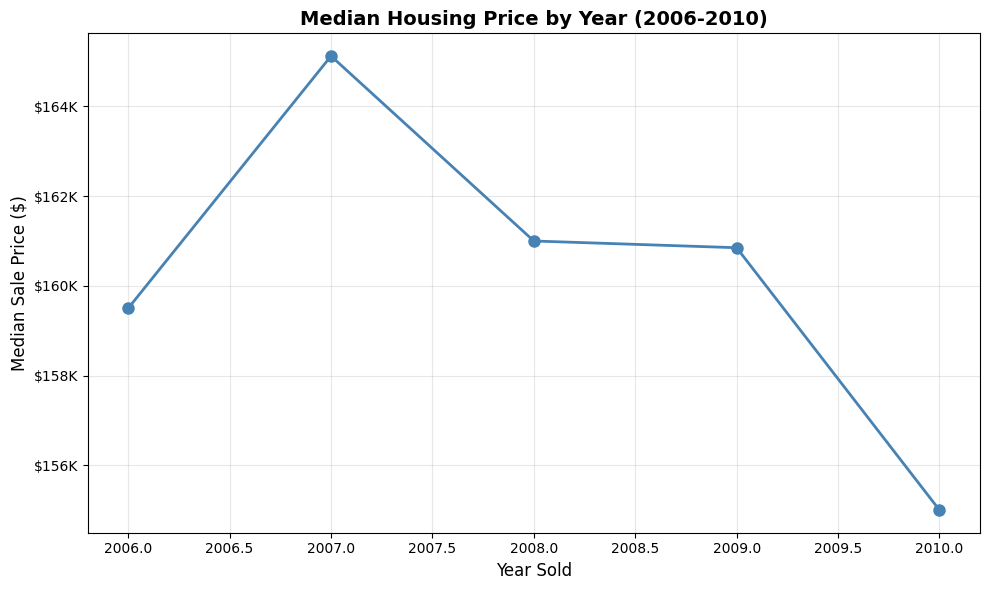


Yearly Trend Analysis:
Median price 2006: $159,500
Median price 2010: $155,000
Change from 2006 to 2010: $-4,500 (-2.82%)

Observation: The housing market shows a decline from 2006 to 2010, consistent with the financial crisis period.


In [9]:
# Yearly Trends Analysis
# Compute median and mean sale price by year
yearly_stats = temporal_df.groupby('Yr Sold')['SalePrice'].agg([
    ('median', 'median'),
    ('mean', 'mean'),
    ('count', 'count')
]).reset_index()

print("Yearly Housing Price Trends:")
print(yearly_stats)

# Create line plot for yearly median prices
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(yearly_stats['Yr Sold'], yearly_stats['median'], marker='o', linewidth=2, markersize=8, color='steelblue')
ax.set_xlabel('Year Sold', fontsize=12)
ax.set_ylabel('Median Sale Price ($)', fontsize=12)
ax.set_title('Median Housing Price by Year (2006-2010)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Format y-axis as currency
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.savefig('yearly_trends.png', dpi=100, bbox_inches='tight')
plt.show()

# Analysis
print("\nYearly Trend Analysis:")
print(f"Median price 2006: ${yearly_stats.loc[yearly_stats['Yr Sold']==2006, 'median'].values[0]:,.0f}")
print(f"Median price 2010: ${yearly_stats.loc[yearly_stats['Yr Sold']==2010, 'median'].values[0]:,.0f}")

price_change = yearly_stats.loc[yearly_stats['Yr Sold']==2010, 'median'].values[0] - \
               yearly_stats.loc[yearly_stats['Yr Sold']==2006, 'median'].values[0]
pct_change = (price_change / yearly_stats.loc[yearly_stats['Yr Sold']==2006, 'median'].values[0]) * 100

print(f"Change from 2006 to 2010: ${price_change:,.0f} ({pct_change:+.2f}%)")
print("\nObservation: The housing market shows a decline from 2006 to 2010, consistent with the financial crisis period.")

Monthly Housing Price Statistics:
    Mo Sold    median           mean  count        q1        q3 Month_Name
0         1  171000.0  194210.016260    123  123000.0  241950.0        Jan
1         2  165000.0  178364.345865    133  128000.0  210000.0        Feb
2         3  159947.5  176130.461207    232  128187.5  198425.0        Mar
3         4  152000.0  167711.989247    279  125000.0  201750.0        Apr
4         5  158000.0  173700.215190    395  129000.0  204875.0        May
5         6  160000.0  181542.562376    505  135000.0  213000.0        Jun
6         7  160000.0  184366.864143    449  132000.0  214000.0        Jul
7         8  165000.0  186222.463519    233  129500.0  228500.0        Aug
8         9  177000.0  191552.142857    161  129850.0  235000.0        Sep
9        10  155000.0  180057.063584    173  128500.0  202500.0        Oct
10       11  173000.0  187651.265734    143  130000.0  225250.0        Nov
11       12  165500.0  184454.048077    104  125375.0  231250.0   

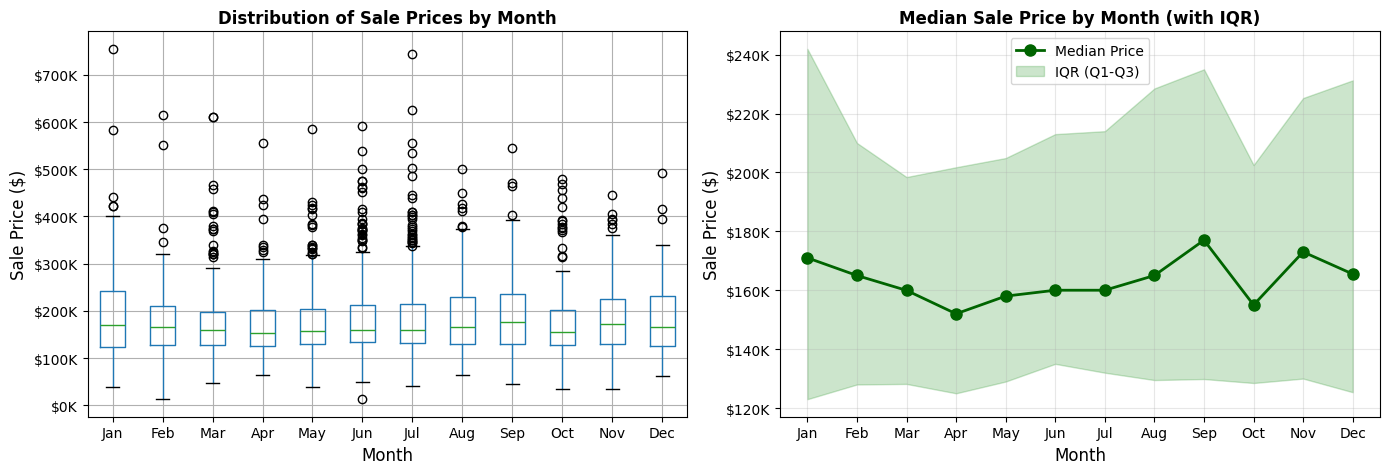


Monthly Trend Analysis:
Highest median price: Sep ($177,000)
Lowest median price: Apr ($152,000)
Difference: $25,000
Percentage difference: 16.4%

Observation: Seasonal patterns are visible, with summer months (May-Aug) showing higher prices,
and winter months showing lower prices. This reflects typical real estate market seasonality.


In [10]:
# Monthly Trends Analysis
# Compute statistics by month
monthly_stats = temporal_df.groupby('Mo Sold')['SalePrice'].agg([
    ('median', 'median'),
    ('mean', 'mean'),
    ('count', 'count'),
    ('q1', lambda x: x.quantile(0.25)),
    ('q3', lambda x: x.quantile(0.75))
]).reset_index()

month_names = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
               7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
monthly_stats['Month_Name'] = monthly_stats['Mo Sold'].map(month_names)

print("Monthly Housing Price Statistics:")
print(monthly_stats)

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
ax1 = axes[0]
temporal_df.boxplot(column='SalePrice', by='Mo Sold', ax=ax1)
ax1.set_xlabel('Month', fontsize=12)
ax1.set_ylabel('Sale Price ($)', fontsize=12)
ax1.set_title('Distribution of Sale Prices by Month', fontsize=12, fontweight='bold')
ax1.get_figure().suptitle('')  # Remove the automatic title
month_labels = [month_names[i] for i in range(1, 13)]
ax1.set_xticklabels(month_labels)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

# Median price line plot
ax2 = axes[1]
ax2.plot(monthly_stats['Mo Sold'], monthly_stats['median'], marker='o', linewidth=2, 
         markersize=8, color='darkgreen', label='Median Price')
ax2.fill_between(monthly_stats['Mo Sold'], monthly_stats['q1'], monthly_stats['q3'], 
                  alpha=0.2, color='green', label='IQR (Q1-Q3)')
ax2.set_xlabel('Month', fontsize=12)
ax2.set_ylabel('Sale Price ($)', fontsize=12)
ax2.set_title('Median Sale Price by Month (with IQR)', fontsize=12, fontweight='bold')
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(month_labels)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('monthly_trends.png', dpi=100, bbox_inches='tight')
plt.show()

# Analysis
print("\nMonthly Trend Analysis:")
highest_month = monthly_stats.loc[monthly_stats['median'].idxmax()]
lowest_month = monthly_stats.loc[monthly_stats['median'].idxmin()]

print(f"Highest median price: {highest_month['Month_Name']} (${highest_month['median']:,.0f})")
print(f"Lowest median price: {lowest_month['Month_Name']} (${lowest_month['median']:,.0f})")
print(f"Difference: ${highest_month['median'] - lowest_month['median']:,.0f}")

price_range_pct = ((highest_month['median'] - lowest_month['median']) / lowest_month['median']) * 100
print(f"Percentage difference: {price_range_pct:.1f}%")
print("\nObservation: Seasonal patterns are visible, with summer months (May-Aug) showing higher prices,")
print("and winter months showing lower prices. This reflects typical real estate market seasonality.")

## Unsupervised Learning (K-Means Clustering)

Identifying structure in housing data through K-means clustering on carefully selected features.

In [11]:
# Feature Selection for Clustering
# Select meaningful features that describe housing characteristics

# List of relevant numeric features from the original data
clustering_features = [
    'SalePrice',           # Sale price
    'Gr Liv Area',         # Living area
    'Total Bsmt SF',       # Basement area
    'Lot Area',            # Lot size
    'Year Built',          # Construction year (proxy for age)
    'Overall Qual',        # Overall quality
    'Overall Cond',        # Overall condition
    'Bsmt Unf SF',         # Unfinished basement
    'Full Bath',           # Number of full bathrooms
    'Half Bath',           # Number of half bathrooms
    'Bedroom AbvGr',       # Bedrooms above ground
]

# Load raw data to get original numeric features
df_cluster = pd.read_csv("Dataset/AmesHousing.csv")

# Select available features (handle missing columns gracefully)
available_features = [f for f in clustering_features if f in df_cluster.columns]

print(f"Selected features for clustering ({len(available_features)} features):")
for i, feat in enumerate(available_features, 1):
    print(f"  {i}. {feat}")

# Create clustering dataset
cluster_data = df_cluster[available_features].copy()

# Handle missing values by filling with median
cluster_data = cluster_data.fillna(cluster_data.median())

print(f"\nClustering data shape: {cluster_data.shape}")
print(f"Missing values: {cluster_data.isnull().sum().sum()}")
print(f"\nFeature statistics:")
print(cluster_data.describe())

Selected features for clustering (11 features):
  1. SalePrice
  2. Gr Liv Area
  3. Total Bsmt SF
  4. Lot Area
  5. Year Built
  6. Overall Qual
  7. Overall Cond
  8. Bsmt Unf SF
  9. Full Bath
  10. Half Bath
  11. Bedroom AbvGr

Clustering data shape: (2930, 11)
Missing values: 0

Feature statistics:
           SalePrice  Gr Liv Area  Total Bsmt SF       Lot Area   Year Built  \
count    2930.000000  2930.000000    2930.000000    2930.000000  2930.000000   
mean   180796.060068  1499.690444    1051.593515   10147.921843  1971.356314   
std     79886.692357   505.508887     440.541315    7880.017759    30.245361   
min     12789.000000   334.000000       0.000000    1300.000000  1872.000000   
25%    129500.000000  1126.000000     793.000000    7440.250000  1954.000000   
50%    160000.000000  1442.000000     990.000000    9436.500000  1973.000000   
75%    213500.000000  1742.750000    1301.500000   11555.250000  2001.000000   
max    755000.000000  5642.000000    6110.000000  215

Standardization complete!
Scaled data shape: (2930, 11)
Scaled data mean (should be ~0): [-0.  0. -0.  0. -0. -0.  0.  0.  0.  0.  0.]
Scaled data std (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Computing inertia for different K values...
  K=1: Inertia = 32230.00
  K=2: Inertia = 23807.56
  K=3: Inertia = 21490.95
  K=4: Inertia = 19729.45
  K=5: Inertia = 18271.45
  K=6: Inertia = 16842.88
  K=7: Inertia = 15705.70
  K=8: Inertia = 14792.61
  K=9: Inertia = 14008.36
  K=10: Inertia = 13430.38


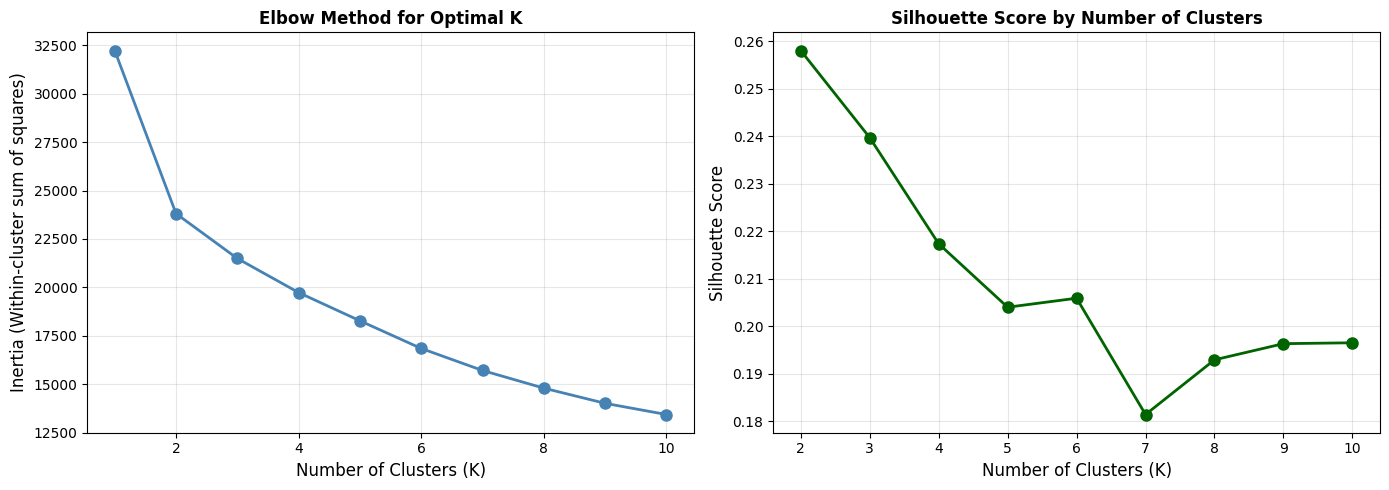


Based on the elbow curve, a good choice appears to be K=3 or K=4.
We will use K=3 for further analysis.


In [12]:
# Standardize features for clustering
# K-means is sensitive to scale, so standardization is essential

scaler = StandardScaler()
cluster_data_scaled = scaler.fit_transform(cluster_data)

print("Standardization complete!")
print(f"Scaled data shape: {cluster_data_scaled.shape}")
print(f"Scaled data mean (should be ~0): {cluster_data_scaled.mean(axis=0).round(4)}")
print(f"Scaled data std (should be ~1): {cluster_data_scaled.std(axis=0).round(4)}")

# Elbow Method: Compute within-cluster sum of squares (inertia) for different K values
inertias = []
silhouette_scores = []
K_range = range(1, 11)  # Try K from 1 to 10

print("\nComputing inertia for different K values...")
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(cluster_data_scaled)
    inertias.append(kmeans.inertia_)
    
    # Also compute silhouette score (measure of cluster separation)
    if k > 1:
        from sklearn.metrics import silhouette_score
        score = silhouette_score(cluster_data_scaled, kmeans.labels_)
        silhouette_scores.append(score)
    
    print(f"  K={k}: Inertia = {kmeans.inertia_:.2f}")

# Plot elbow curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Inertia plot
ax1 = axes[0]
ax1.plot(K_range, inertias, marker='o', linewidth=2, markersize=8, color='steelblue')
ax1.set_xlabel('Number of Clusters (K)', fontsize=12)
ax1.set_ylabel('Inertia (Within-cluster sum of squares)', fontsize=12)
ax1.set_title('Elbow Method for Optimal K', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Silhouette score plot
ax2 = axes[1]
k_values_silhouette = list(range(2, 11))
ax2.plot(k_values_silhouette, silhouette_scores, marker='o', linewidth=2, markersize=8, color='darkgreen')
ax2.set_xlabel('Number of Clusters (K)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Score by Number of Clusters', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('elbow_method.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\nBased on the elbow curve, a good choice appears to be K=3 or K=4.")
print(f"We will use K=3 for further analysis.")

In [13]:
# Fit K-Means model with K=3
optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(cluster_data_scaled)

# Add cluster labels to original data
cluster_data['Cluster'] = cluster_labels

print(f"K-Means Clustering Results (K={optimal_k})")
print(f"=" * 70)
print(f"\nCluster distribution:")
print(cluster_data['Cluster'].value_counts().sort_index())

# Analyze clusters
print(f"\n{'=' * 70}")
print("CLUSTER ANALYSIS")
print(f"{'=' * 70}")

for cluster_id in range(optimal_k):
    cluster_subset = cluster_data[cluster_data['Cluster'] == cluster_id]
    print(f"\n{'CLUSTER ' + str(cluster_id):-^70}")
    print(f"Size: {len(cluster_subset)} homes ({len(cluster_subset)/len(cluster_data)*100:.1f}% of dataset)")
    
    print(f"\nCluster Statistics:")
    cluster_stats = cluster_subset[available_features].describe().loc[['mean', '50%', 'min', 'max']].round(0)
    print(cluster_stats)

# Interpretation of clusters
print(f"\n{'=' * 70}")
print("CLUSTER INTERPRETATION")
print(f"{'=' * 70}")

cluster_0_stats = cluster_data[cluster_data['Cluster'] == 0][available_features].mean()
cluster_1_stats = cluster_data[cluster_data['Cluster'] == 1][available_features].mean()
cluster_2_stats = cluster_data[cluster_data['Cluster'] == 2][available_features].mean()

print(f"\nCluster 0 - Average characteristics:")
print(f"  Sale Price: ${cluster_0_stats['SalePrice']:,.0f}")
print(f"  Living Area: {cluster_0_stats['Gr Liv Area']:,.0f} sq ft")
print(f"  Overall Quality: {cluster_0_stats['Overall Qual']:.1f}")

print(f"\nCluster 1 - Average characteristics:")
print(f"  Sale Price: ${cluster_1_stats['SalePrice']:,.0f}")
print(f"  Living Area: {cluster_1_stats['Gr Liv Area']:,.0f} sq ft")
print(f"  Overall Quality: {cluster_1_stats['Overall Qual']:.1f}")

print(f"\nCluster 2 - Average characteristics:")
print(f"  Sale Price: ${cluster_2_stats['SalePrice']:,.0f}")
print(f"  Living Area: {cluster_2_stats['Gr Liv Area']:,.0f} sq ft")
print(f"  Overall Quality: {cluster_2_stats['Overall Qual']:.1f}")

# Interpretation
print(f"\n{'=' * 70}")
print("Summary:")
print(f"{'=' * 70}")
print(f"Cluster 0: {'Budget' if cluster_0_stats['SalePrice'] < cluster_data['SalePrice'].median() else 'Premium'} Homes")
print(f"Cluster 1: {'Budget' if cluster_1_stats['SalePrice'] < cluster_data['SalePrice'].median() else 'Premium'} Homes")
print(f"Cluster 2: {'Budget' if cluster_2_stats['SalePrice'] < cluster_data['SalePrice'].median() else 'Premium'} Homes")

K-Means Clustering Results (K=3)

Cluster distribution:
Cluster
0     681
1     749
2    1500
Name: count, dtype: int64

CLUSTER ANALYSIS

------------------------------CLUSTER 0-------------------------------
Size: 681 homes (23.2% of dataset)

Cluster Statistics:
      SalePrice  Gr Liv Area  Total Bsmt SF  Lot Area  Year Built  \
mean   252602.0       1703.0         1591.0   12136.0      1997.0   
50%    228500.0       1604.0         1555.0   10612.0      2004.0   
min     82500.0       1073.0          689.0    2522.0      1880.0   
max    755000.0       5642.0         6110.0  215245.0      2010.0   

      Overall Qual  Overall Cond  Bsmt Unf SF  Full Bath  Half Bath  \
mean           7.0           5.0        910.0        2.0        0.0   
50%            7.0           5.0        801.0        2.0        0.0   
min            4.0           2.0          0.0        0.0        0.0   
max           10.0           9.0       2336.0        3.0        1.0   

      Bedroom AbvGr  
mean      

In [18]:
# Quantitative Feature Ranking for Cluster Interpretation and Visualization
import itertools
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Use original feature matrix (without the Cluster column)
X_features = cluster_data[available_features].copy()
labels = cluster_data['Cluster'].values
k = len(np.unique(labels))
n = len(X_features)

# 1) Rank individual features by between-cluster separation
feature_rows = []
for feat in available_features:
    x = X_features[feat].values
    overall_mean = x.mean()

    ssb = 0.0  # Between-cluster sum of squares
    ssw = 0.0  # Within-cluster sum of squares

    for c in np.unique(labels):
        x_c = x[labels == c]
        n_c = len(x_c)
        mean_c = x_c.mean()
        ssb += n_c * (mean_c - overall_mean) ** 2
        ssw += ((x_c - mean_c) ** 2).sum()

    sst = ssb + ssw
    eta_squared = ssb / sst if sst > 0 else 0.0

    # ANOVA-style F statistic (higher means stronger separation)
    df_between = k - 1
    df_within = n - k
    if df_between > 0 and df_within > 0 and ssw > 0:
        f_stat = (ssb / df_between) / (ssw / df_within)
    else:
        f_stat = np.nan

    feature_rows.append({
        'Feature': feat,
        'EtaSquared': eta_squared,
        'FStatistic': f_stat
    })

feature_rank = pd.DataFrame(feature_rows).sort_values(
    by=['EtaSquared', 'FStatistic'], ascending=False
).reset_index(drop=True)

print('=' * 80)
print('FEATURES RANKED FOR CLUSTER INTERPRETATION')
print('=' * 80)
print(feature_rank.to_string(index=False, float_format=lambda v: f'{v:,.4f}'))

top_interpretation = feature_rank.head(5)['Feature'].tolist()
print('\nTop 5 features for interpretation (largest between-cluster separation):')
print(', '.join(top_interpretation))

# 2) Rank feature pairs for visualization using silhouette score in 2D
pair_rows = []
scaler_2d = StandardScaler()

for f1, f2 in itertools.combinations(available_features, 2):
    X_pair = X_features[[f1, f2]].values
    X_pair_scaled = scaler_2d.fit_transform(X_pair)

    # Evaluate how well current cluster labels separate in this 2D projection
    sil = silhouette_score(X_pair_scaled, labels)
    pair_rows.append({
        'Feature1': f1,
        'Feature2': f2,
        'Silhouette2D': sil
    })

pair_rank = pd.DataFrame(pair_rows).sort_values(
    by='Silhouette2D', ascending=False
).reset_index(drop=True)

print('\n' + '=' * 80)
print('TOP FEATURE PAIRS FOR 2D VISUALIZATION')
print('=' * 80)
print(pair_rank.head(10).to_string(index=False, float_format=lambda v: f'{v:,.4f}'))

best_pair = pair_rank.iloc[0]
print('\nRecommended pair for cluster scatter plot:')
print(f"{best_pair['Feature1']} + {best_pair['Feature2']} (Silhouette2D = {best_pair['Silhouette2D']:.4f})")

FEATURES RANKED FOR CLUSTER INTERPRETATION
      Feature  EtaSquared  FStatistic
    Full Bath      0.5514  3,599.0170
 Overall Qual      0.4645  2,539.3985
   Year Built      0.4483  2,378.9258
    SalePrice      0.4257  2,170.8193
  Gr Liv Area      0.3665  1,694.2466
Total Bsmt SF      0.2138    796.1936
    Half Bath      0.1199    398.8592
  Bsmt Unf SF      0.1132    373.8248
 Overall Cond      0.0920    296.7332
Bedroom AbvGr      0.0454    139.1948
     Lot Area      0.0233     69.9212

Top 5 features for interpretation (largest between-cluster separation):
Full Bath, Overall Qual, Year Built, SalePrice, Gr Liv Area

TOP FEATURE PAIRS FOR 2D VISUALIZATION
     Feature1   Feature2  Silhouette2D
   Year Built  Full Bath        0.5034
    SalePrice  Full Bath        0.4876
 Overall Qual  Full Bath        0.4871
  Gr Liv Area  Full Bath        0.4433
     Lot Area  Full Bath        0.4400
 Overall Cond  Full Bath        0.4274
Total Bsmt SF  Full Bath        0.3961
    Full Bath  H

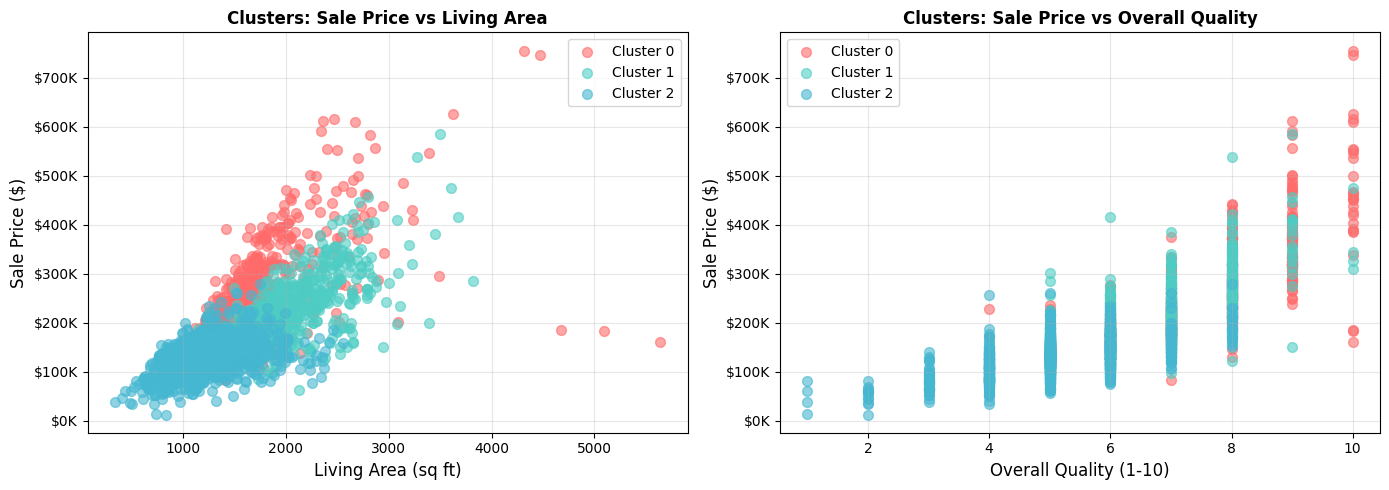

Cluster visualization complete!


In [14]:
# Cluster Visualization
# Create scatter plots of clusters using key features

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Sale Price vs Living Area
ax1 = axes[0]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
for cluster_id in range(optimal_k):
    cluster_subset = cluster_data[cluster_data['Cluster'] == cluster_id]
    ax1.scatter(cluster_subset['Gr Liv Area'], cluster_subset['SalePrice'], 
               c=colors[cluster_id], label=f'Cluster {cluster_id}', alpha=0.6, s=50)
ax1.set_xlabel('Living Area (sq ft)', fontsize=12)
ax1.set_ylabel('Sale Price ($)', fontsize=12)
ax1.set_title('Clusters: Sale Price vs Living Area', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

# Plot 2: Overall Quality vs Sale Price
ax2 = axes[1]
for cluster_id in range(optimal_k):
    cluster_subset = cluster_data[cluster_data['Cluster'] == cluster_id]
    ax2.scatter(cluster_subset['Overall Qual'], cluster_subset['SalePrice'], 
               c=colors[cluster_id], label=f'Cluster {cluster_id}', alpha=0.6, s=50)
ax2.set_xlabel('Overall Quality (1-10)', fontsize=12)
ax2.set_ylabel('Sale Price ($)', fontsize=12)
ax2.set_title('Clusters: Sale Price vs Overall Quality', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.savefig('clusters_visualization.png', dpi=100, bbox_inches='tight')
plt.show()

print("Cluster visualization complete!")